In [30]:
import numpy as np

In [31]:
class Value:
    def __init__(self, value, children = (), op = ''):
        
        self.value = value
        self._prev = children
        self._op = op

    def __repr__(self):
        
        return f'Value <data = {self.value}>'

    def __add__(self, other):

        if isinstance(other, Value):
            new_val = other.value
        else:
            return NotImplemented
        
        return Value(new_val + self.value, (self, other), '+')

    def __sub__(self, other):
        
        if isinstance(other, Value):
            new_val = other.value
        else:
            return NotImplemented
        
        return Value(self.value - new_val, (self, other), '+')

    def __mul__(self, other):
        
        if isinstance(other, Value):
            new_val = other.value
        else:
            return NotImplemented
        
        return Value(new_val * self.value, (self, other), '*')

    def __truediv__(self, other):
        
        if isinstance(other, Value):
            new_val = other.value
        else:
            return NotImplemented
        
        return Value(self.value / new_val, (self, other), '/')
        

In [32]:
a = Value(2)
b = Value(100)
c = a+b
h = Value(0.000001)

f = a + b*b + c*c*c

c += h

new_f = a + b*b + c*c*c

d = (new_f - f) / h

d

Value <data = 31212.00017631054>

In [33]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ value %.4f }" % (n.value), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

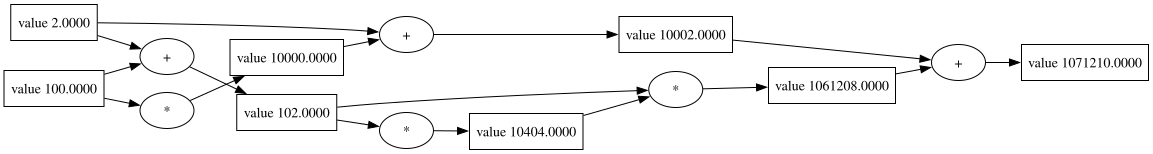

In [34]:
draw_dot(f)